### **TASK 4** · Email Spam Detection with Machine Learning
#### **Objective**: Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.
##### **Tech Stack**: Python, pandas, scikit-learn (TF-IDF, Naive Bayes/SVM), NLTK or re, Jupyter Notebook


### Import all the libraries 

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score , recall_score , f1_score ,confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

### Load the Dataset

In [78]:
data = pd.read_csv('spam.csv', encoding="latin-1")
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [79]:
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

In [80]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [81]:
data.shape

(5572, 2)

In [82]:
data.columns

Index(['v1', 'v2'], dtype='str')

In [83]:
data.duplicated().sum()

np.int64(403)

In [84]:
data=data.drop_duplicates()

In [85]:
data.duplicated().sum()

np.int64(0)

In [86]:
data = data.rename(columns={
    'v1':'Label',
    'v2':'Message',
})

In [87]:
data.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [88]:
data['Label'].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

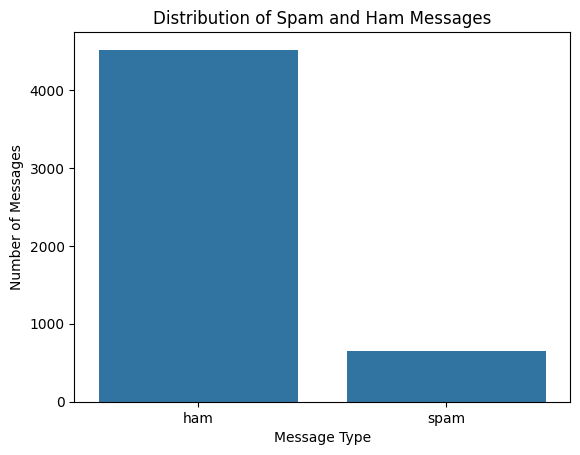

In [89]:
sns.countplot(x='Label', data=data)
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

### Observation

The dataset contains both spam and ham messages. The number of ham messages is significantly higher than the number of spam messages, indicating that the dataset is imbalanced.

In [90]:
data['Message_length']=data['Message'].apply(len)

In [91]:
data[['Message', 'Message_length']].head()

,Message,Message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [92]:
data.groupby('Label')['Message_length'].mean()

Label
ham      70.459256
spam    137.891271
Name: Message_length, dtype: float64

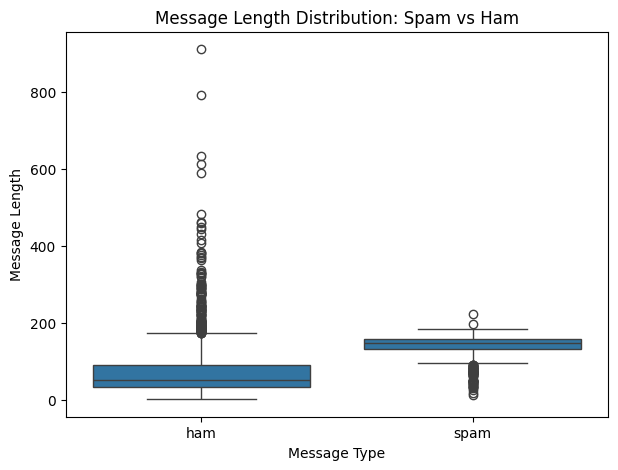

In [93]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Label',
    y='Message_length',
    data=data
)

plt.title("Message Length Distribution: Spam vs Ham")
plt.xlabel("Message Type")
plt.ylabel("Message Length")

plt.show()

In [94]:
data['word_count'] = data['Message'].apply(lambda x: len(x.split()))
data['word_count'].head()

0    20
1     6
2    28
3    11
4    13
Name: word_count, dtype: int64

In [95]:
data.groupby('Label')[['Message_length', 'word_count']].mean()

,Message_length,word_count
Label,,
ham,70.459256,14.134632
spam,137.891271,23.681470


### Observation

Message length and word count were analyzed for spam and ham messages. The distributions show differences in the typical length of messages between the two categories. These features provide useful insights during exploratory data analysis, although the final spam classification will use TF-IDF text features.

In [96]:
def clean_text(text):
    text = text.lower()
    text = re.sub('r[^a-zA-Z\s]','',text)
    return text

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\bipin\AppData\Local\Temp\ipykernel_17184\1725294067.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  text = re.sub('r[^a-zA-Z\s]','',text)


In [97]:
data['clean_message'] = data['Message'].apply(clean_text)

In [98]:
data[['Message','clean_message']]

,Message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok la.. joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early ho.. u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,this is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?,will ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s...","pity, * was in mood for that. so...any other s..."
5570,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like i'd...


### Text Normalization

All uppercase characters were converted to lowercase to maintain consistency in
the text data. This ensures that words such as "FREE" and "free" are treated as
the same word during feature extraction, reducing unnecessary variation in the
text.

# Train/Test Split Data

In [99]:

X=data['clean_message']
y=data['Label']

X_train_text, X_test_text, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [100]:
tfid = TfidfVectorizer()

In [101]:
X_train = tfid.fit_transform(X_train_text)

In [102]:
X_test = tfid.transform(X_test_text)

In [103]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (4135, 7750)
Testing shape: (1034, 7750)


In [104]:

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [105]:
lr_predictions = lr_model.predict(X_test)

In [106]:
print(lr_predictions[:10])

['ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'ham' 'spam' 'ham' 'ham']


In [107]:

print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions, pos_label='spam'))
print("Recall   :", recall_score(y_test, lr_predictions, pos_label='spam'))
print("F1 Score :", f1_score(y_test, lr_predictions, pos_label='spam'))

Logistic Regression Results
Accuracy : 0.9700193423597679
Precision: 0.975
Recall   : 0.8068965517241379
F1 Score : 0.8830188679245283


# Navie Bayes Model

In [108]:
nb_model = MultinomialNB()

In [109]:
nb_model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [110]:
nb_predictions = nb_model.predict(X_test)

In [111]:
print("Naive Bayes Results")

print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions, pos_label='spam'))
print("Recall   :", recall_score(y_test, nb_predictions, pos_label='spam'))
print("F1 Score :", f1_score(y_test, nb_predictions, pos_label='spam'))

Naive Bayes Results
Accuracy : 0.9555125725338491
Precision: 1.0
Recall   : 0.6827586206896552
F1 Score : 0.8114754098360656


In [112]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, nb_predictions)
    ],
    'Precision': [
        precision_score(y_test, lr_predictions, pos_label='spam'),
        precision_score(y_test, nb_predictions, pos_label='spam')
    ],
    'Recall': [
        recall_score(y_test, lr_predictions, pos_label='spam'),
        recall_score(y_test, nb_predictions, pos_label='spam')
    ],
    'F1 Score': [
        f1_score(y_test, lr_predictions, pos_label='spam'),
        f1_score(y_test, nb_predictions, pos_label='spam')
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.970019,0.975,0.806897,0.883019
1,Naive Bayes,0.955513,1.000,0.682759,0.811475


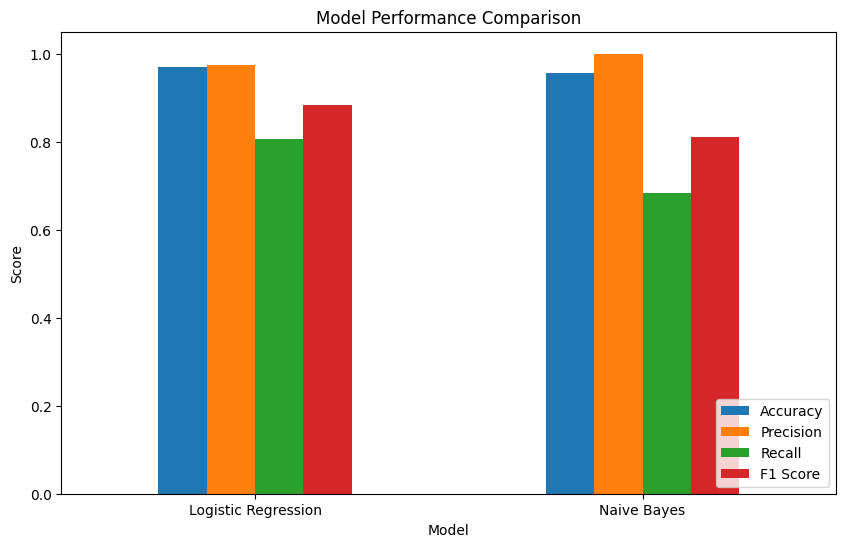

In [113]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

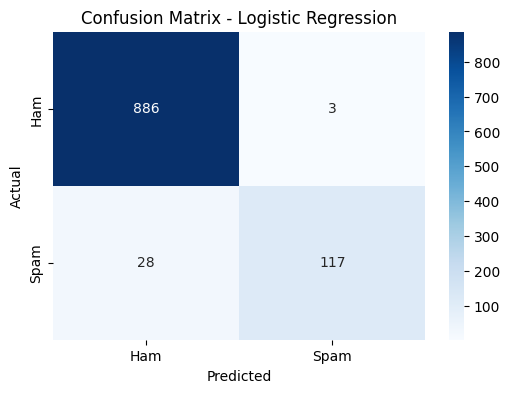

In [114]:
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The dataset was split into 80% training and 20% testing data. TF-IDF was used to 
convert text messages into numerical features. Two models, Logistic Regression 
and Naive Bayes, were trained and evaluated. Logistic Regression achieved better 
overall performance with approximately 97% accuracy and an F1-score of 88.30%, 
making it the preferred model for this spam detection task.

In [115]:
def predict_message(message):
    cleaned_message = clean_text(message)

    message_tfidf = tfid.transform([cleaned_message])

    prediction = lr_model.predict(message_tfidf)[0]

    return prediction

In [116]:
message = "Congratulations! You have won a free iPhone. Click now to claim your prize!"

print("Prediction:", predict_message(message))

Prediction: spam


In [117]:
message = "Hey bro, are you coming to college tomorrow?"

print("Prediction:", predict_message(message))

Prediction: ham


In [118]:
test_messages = [
    "Congratulations! You won a free prize. Click here now!",
    "Hey bro, what are you doing?",
    "URGENT! You have won a cash reward. Call now!",
    "Can you send me the notes from today's lecture?"
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_message(message),'\n')

Message: Congratulations! You won a free prize. Click here now!
Prediction: spam 

Message: Hey bro, what are you doing?
Prediction: ham 

Message: URGENT! You have won a cash reward. Call now!
Prediction: spam 

Message: Can you send me the notes from today's lecture?
Prediction: ham 



### Why is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures how many of the
actual spam messages are correctly identified by the model. A low recall means that
many spam messages are being incorrectly classified as legitimate (ham), allowing
them to reach the user's inbox.

Therefore, a higher recall helps the model detect more of the actual spam messages
and reduces the number of missed spam emails.